# 02 · Outlier Detection and Handling

        > Part of the **Data Preprocessing** module — taught alongside the `data/customer_churn.csv` dataset.

        ## Learning objectives
        - Spot outliers visually (boxplot, histogram) and statistically (IQR, Z-score, MAD)
- Use Isolation Forest and LOF for multivariate outliers
- Decide between *removing*, *capping (winsorising)*, and *transforming*
- Avoid the trap of treating all extremes as bad

        ---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

df = pd.read_csv("data/customer_churn.csv")
print("shape:", df.shape)
df.head()

shape: (5000, 15)


,customer_id,age,gender,city,education,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_products,has_credit_card,is_active_member,estimated_salary,churned
0,10000,46.0,Male,Bengaluru,Bachelors,40,Month-to-month,Electronic check,16.90,686.72,3,1,0,55083.68,1
1,10001,28.0,Female,Chennai,Masters,22,One year,Credit card,88.73,NaN,2,1,0,75325.39,0
2,10002,52.0,Female,Mumbai,Bachelors,7,Two year,Mailed check,67.45,449.61,1,1,1,57584.71,0
3,10003,54.0,Male,Delhi,Bachelors,31,One year,Bank transfer,48.61,1615.53,1,1,0,57525.63,0
4,10004,18.0,Male,Delhi,Bachelors,18,Month-to-month,Bank transfer,90.82,1612.81,1,1,0,103508.09,0


## 1. What is an outlier?

A point far from the rest of the data. **Outlier ≠ error.** A genuine extreme observation
can be the most important point in your dataset (fraud, churn, equipment failure).

Two questions before any handling:
1. Is it a *data error* (typo, unit mix-up) or a *real* extreme?
2. Will it distort the model I'm planning to fit?

Tree-based models tolerate outliers well. Linear models, distance-based models (KNN, k-means),
and PCA do not.

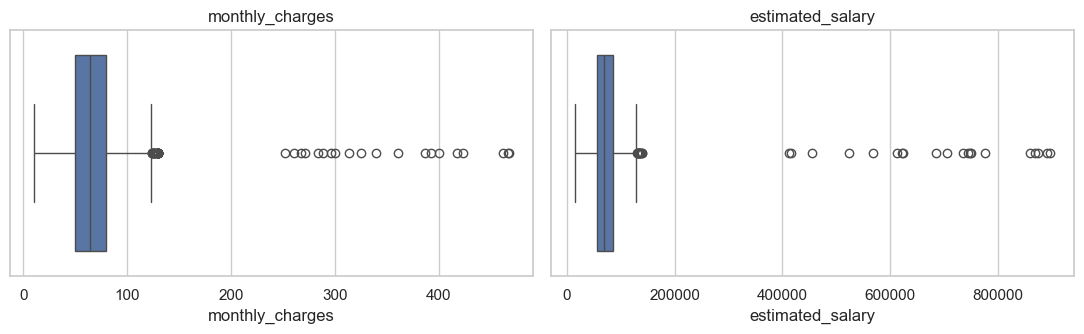

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

sns.boxplot(x=df["monthly_charges"], ax=axes[0])
axes[0].set_title("monthly_charges")

sns.boxplot(x=df["estimated_salary"], ax=axes[1])
axes[1].set_title("estimated_salary")

plt.tight_layout()
plt.show()

## 2. IQR method (Tukey's fences)

A point is an outlier if it falls below `Q1 − 1.5·IQR` or above `Q3 + 1.5·IQR`.
Robust because it ignores the tails when computing the cutoffs. Works on any distribution
shape.

In [3]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

for col in ["monthly_charges", "estimated_salary"]:
    low, high = iqr_bounds(df[col])
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col:20s}  bounds=({low:.0f}, {high:.0f})  outliers={n_out}")

monthly_charges       bounds=(6, 123)  outliers=42
estimated_salary      bounds=(10635, 130391)  outliers=32


## 3. Z-score method

A point is an outlier if `|z| > 3` where `z = (x − mean) / std`.
Assumes the column is roughly Gaussian — use it on near-normal columns only. The mean and
std are themselves pulled by outliers, which is why people prefer the next method.

In [4]:
from scipy import stats
z = np.abs(stats.zscore(df["monthly_charges"], nan_policy="omit"))
print("monthly_charges z>3 outliers:", (z > 3).sum())

monthly_charges z>3 outliers: 20


## 4. Modified Z-score (MAD)

Uses **median absolute deviation** instead of mean/std → robust to the very outliers
you're trying to detect. Threshold ≈ 3.5.

`mod_z = 0.6745 · (x − median) / MAD`

In [5]:
def modified_zscore(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    return 0.6745 * (x - med) / (mad if mad else 1)

mz = modified_zscore(df["monthly_charges"])
print("monthly_charges |mod_z|>3.5 outliers:", (np.abs(mz) > 3.5).sum())

monthly_charges |mod_z|>3.5 outliers: 20


## 5. Multivariate outliers — Isolation Forest

A point can look normal in every column individually but be weird *in combination*
(e.g. a 22-year-old earning ₹5 lakh/month with a 60-month tenure). Univariate methods miss these.

Isolation Forest builds random trees; outliers are the points that get isolated in *fewer*
splits.

In [10]:
from sklearn.ensemble import IsolationForest

iso_features = ["age", "tenure_months", "monthly_charges", "estimated_salary"]
sub = df[iso_features].dropna()

iso = IsolationForest(contamination=0.02, random_state=42)
is_outlier = iso.fit_predict(sub) == -1
print(f"Isolation Forest flagged {is_outlier.sum()} of {len(sub)} rows ({is_outlier.mean():.1%})")
sub.loc[is_outlier]

Isolation Forest flagged 87 of 4333 rows (2.0%)


,age,tenure_months,monthly_charges,estimated_salary
179,46.0,32,267.18,89495.32
211,25.0,10,260.59,77812.36
248,80.0,62,23.98,70610.03
337,46.0,44,423.16,114262.36
618,34.0,1,77.22,747924.85
...,...,...,...,...
4490,65.0,69,118.26,113332.33
4523,43.0,68,313.07,83558.83
4592,45.0,8,127.11,522919.83
4852,68.0,19,13.17,78944.52


## 6. Local Outlier Factor (LOF)

Compares the local density of a point to the densities of its neighbours. Good for
clustered data where global thresholds don't make sense.

In [7]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
lof_flag = lof.fit_predict(sub) == -1
print(f"LOF flagged {lof_flag.sum()} rows")

LOF flagged 87 rows


## 7. Handling — three options

### a) Remove (use sparingly)
Only when you're sure they're errors. You lose information otherwise.

### b) Cap / Winsorise
Clip values to the IQR fences (or the 1st/99th percentile). Keeps the row but tames
the extreme.

### c) Transform
A `log1p` or square-root transform pulls the long tail in. Often eliminates the
"outlier" entirely without removing data.

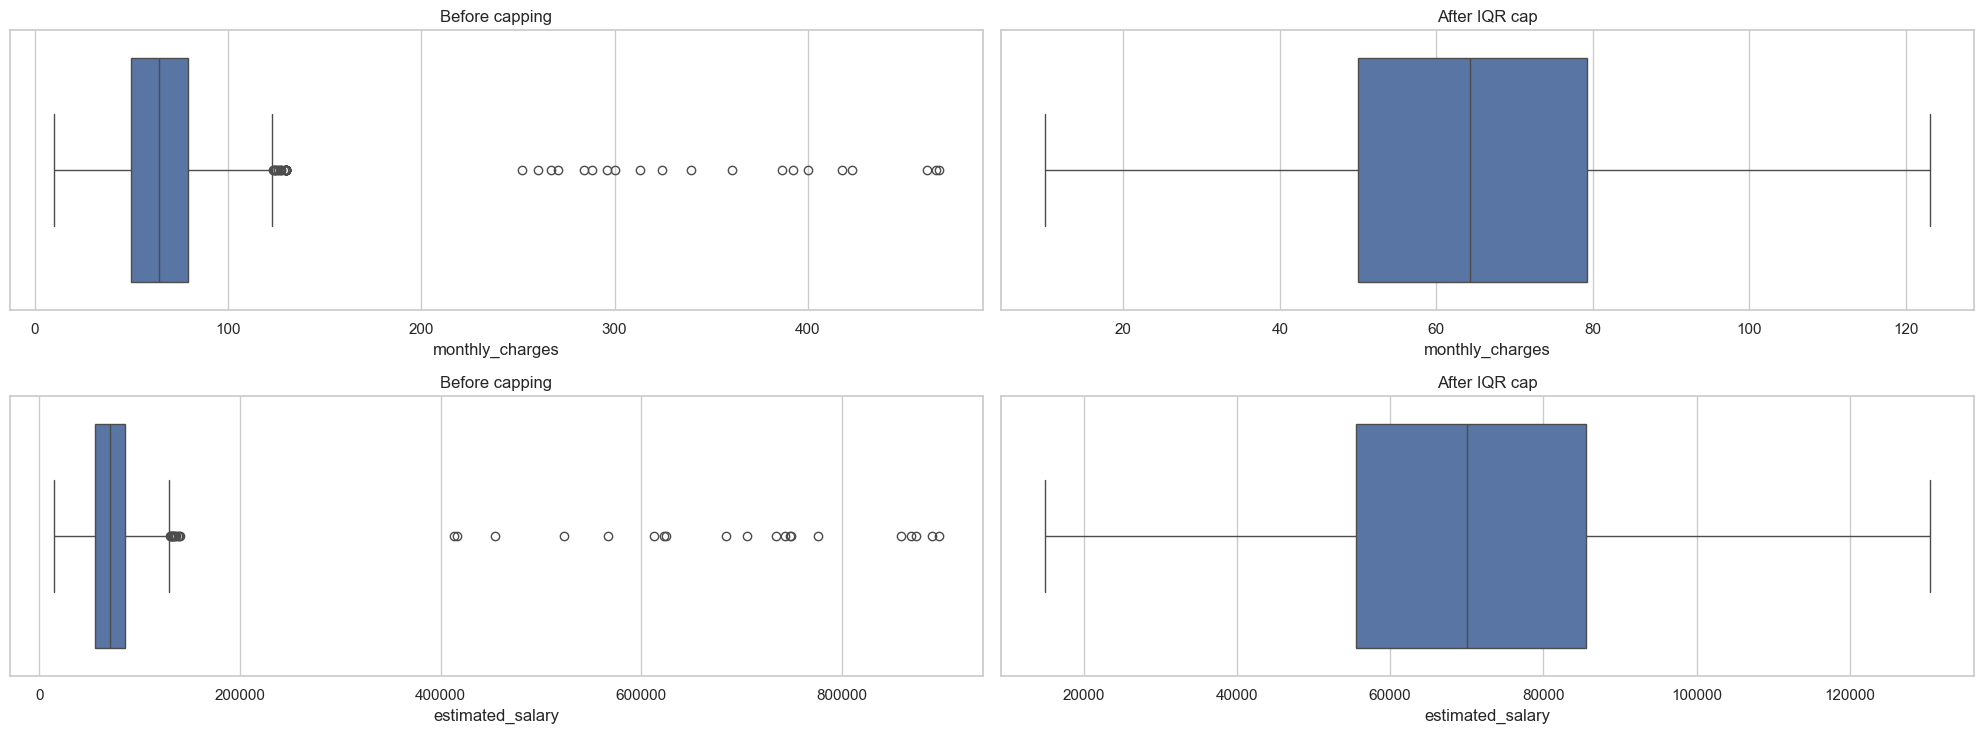

In [17]:
df_capped = df.copy()
for col in ["monthly_charges", "estimated_salary"]:
    lo, hi = iqr_bounds(df_capped[col])
    df_capped[col] = df_capped[col].clip(lo, hi)

fig, axes = plt.subplots(2, 2, figsize=(20, 7.5), sharey=True)
sns.boxplot(x=df["monthly_charges"], ax=axes[0, 0]).set(title="Before capping")
sns.boxplot(x=df_capped["monthly_charges"], ax=axes[0, 1]).set(title="After IQR cap")
sns.boxplot(x=df["estimated_salary"], ax=axes[1, 0]).set(title="Before capping")
sns.boxplot(x=df_capped["estimated_salary"], ax=axes[1, 1]).set(title="After IQR cap")
plt.tight_layout(); plt.show()

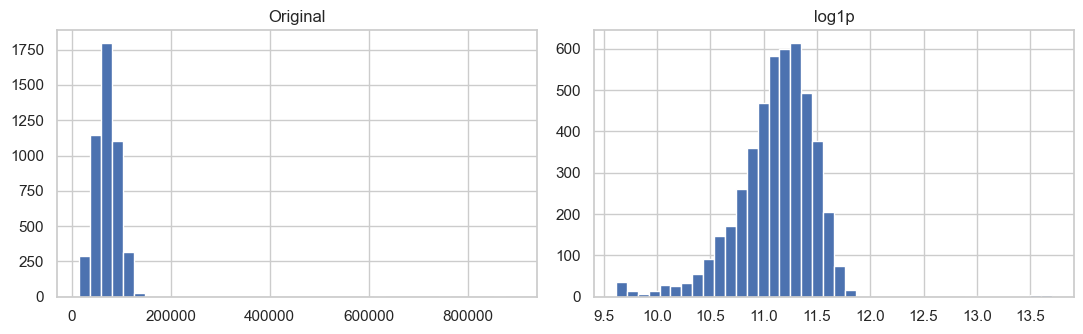

In [9]:
# Log transform on a long-tailed column
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
df["estimated_salary"].hist(bins=40, ax=axes[0]); axes[0].set_title("Original")
np.log1p(df["estimated_salary"]).hist(bins=40, ax=axes[1]); axes[1].set_title("log1p")
plt.tight_layout(); plt.show()

## 8. Decision guide

| Situation | Action |
|-----------|--------|
| Clear data error (impossible value) | drop or fix |
| Real extreme, linear/distance model | cap or transform |
| Real extreme, tree model | usually leave alone |
| Multivariate weirdness | Isolation Forest / LOF + investigate |
| Imbalanced rare class (e.g. fraud) | the "outliers" are your signal — keep them |

## Exercise
1. Apply the IQR cap only on the training set (not test) — why does that order matter?
2. Compare logistic-regression accuracy with vs without log-transforming `estimated_salary`.